In [2]:
import zipfile
with zipfile.ZipFile("ml-100k.zip", "r") as zip_ref:
    zip_ref.extractall(".")
print("✅ Extracted!")

✅ Extracted!


In [3]:
import subprocess
subprocess.run(["pip", "install", "scikit-surprise"])
print("✅ Surprise installed!")

✅ Surprise installed!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ratings = pd.read_csv("ml-100k/u.data", sep="\t",
    names=["userId","movieId","rating","timestamp"])

movies = pd.read_csv("ml-100k/u.item", sep="|",
    encoding="latin-1",
    names=["movieId","title","release_date","video_release_date",
           "IMDb_URL","unknown","Action","Adventure","Animation",
           "Children","Comedy","Crime","Documentary","Drama",
           "Fantasy","Film-Noir","Horror","Musical","Mystery",
           "Romance","Sci-Fi","Thriller","War","Western"])

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print(ratings.head())

Ratings shape: (100000, 4)
Movies shape: (1682, 24)
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

genre_cols = ["Action","Adventure","Animation","Children",
              "Comedy","Crime","Documentary","Drama","Fantasy",
              "Film-Noir","Horror","Musical","Mystery","Romance",
              "Sci-Fi","Thriller","War","Western"]

movies["genres"] = movies[genre_cols].apply(
    lambda row: " ".join([g for g in genre_cols if row[g]==1]), axis=1)

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies["genres"])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
movie_idx = pd.Series(movies.index, index=movies["title"])

def recommend_movies(title, n=5):
    idx = movie_idx[title]
    sim_scores = sorted(enumerate(cosine_sim[idx]),
                       key=lambda x: x[1], reverse=True)[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies.iloc[movie_indices][["title","genres"]]

print("✅ Content-Based system ready!")
print("\nMovies similar to Toy Story:")
print(recommend_movies("Toy Story (1995)"))

✅ Content-Based system ready!

Movies similar to Toy Story:
                                      title                     genres
421  Aladdin and the King of Thieves (1996)  Animation Children Comedy
101                  Aristocats, The (1970)         Animation Children
403                        Pinocchio (1940)         Animation Children
624          Sword in the Stone, The (1963)         Animation Children
945           Fox and the Hound, The (1981)         Animation Children


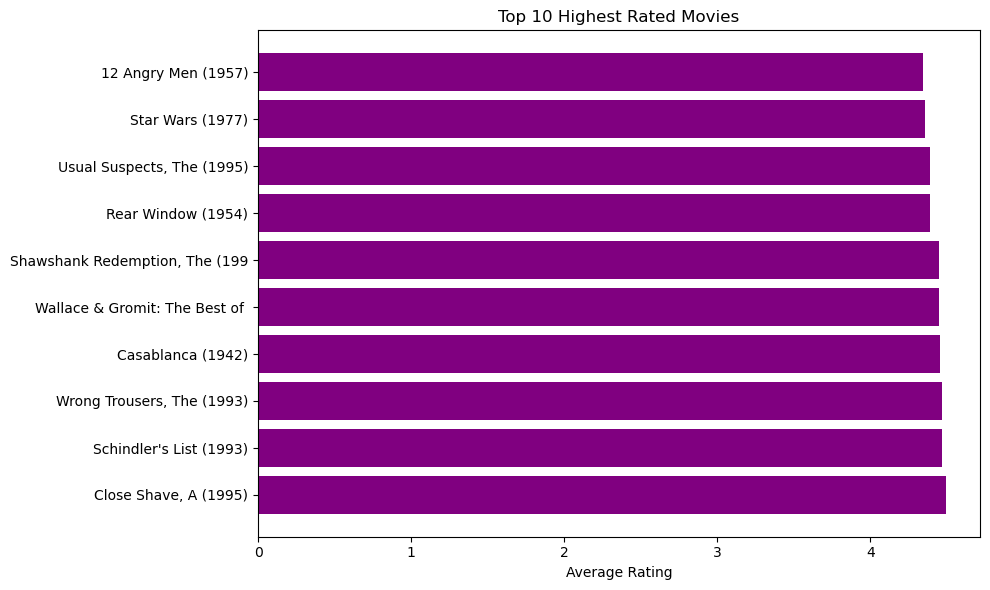

🎉 Movie Recommendation Project Complete!


In [6]:
# Top rated movies chart
top_movies = ratings.groupby("movieId")["rating"].agg(
    ["mean","count"]).reset_index()
top_movies = top_movies[top_movies["count"] > 50]
top_movies = top_movies.merge(
    movies[["movieId","title"]], on="movieId")
top_movies = top_movies.sort_values(
    "mean", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_movies["title"].str[:30],
         top_movies["mean"], color="purple")
plt.xlabel("Average Rating")
plt.title("Top 10 Highest Rated Movies")
plt.tight_layout()
plt.savefig("movie_recommendation_result.png")
plt.show()
print("🎉 Movie Recommendation Project Complete!")